<a href="https://colab.research.google.com/github/Yongyong-2/Quantum-Computing-Practice/blob/main/Module01/First_Quantum_Circuit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 06 - First Quantum Circuit

## Goal

Create and execute the first quantum circuit using Qiskit.

Today we will learn:

- QuantumCircuit
- Qubit
- Classical Bit
- Measurement



In [2]:
!pip install qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=fb7af8d1648bbcbf928e5cfc2fc3b60f0c88f3ae786db361e20ab3f8b5eab503
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

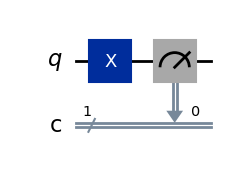

In [4]:
qc = QuantumCircuit(1,1)
qc.x(0)
qc.measure(0,0)
qc.draw("mpl")

In [5]:
sim = AerSimulator()
job = sim.run(qc, shots=1000)
result = job.result()
counts = result.get_counts()
print(counts)

{'1': 1000}


In [6]:
from qiskit.quantum_info import Statevector

In [7]:
qc = QuantumCircuit(1)

qc.x(0)
qc.h(0)
state = Statevector.from_instruction(qc)
state.draw("latex")
print(state)

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


In [8]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)

print("초기 상태")
print(Statevector.from_instruction(qc))

qc.x(0)

print("\nX Gate 이후")
print(Statevector.from_instruction(qc))

qc = QuantumCircuit(1)

qc.h(0)

print("\nH Gate 이후")
print(Statevector.from_instruction(qc))

초기 상태
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

X Gate 이후
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))

H Gate 이후
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [9]:
qc = QuantumCircuit(1,1)
qc.h(0) # Hadamard Gate 적용
qc.measure(0,0)
sim = AerSimulator()
result = sim.run(qc, shots=1000000).result()
print(result.get_counts())

{'1': 499971, '0': 500029}


## Hadamard Gate

Hadamard Gate는 큐비트를 **중첩(Superposition)** 상태로 만드는 게이트이다.

$$
H=\frac{1}{\sqrt2}
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}
$$

상태 변화

$$
H|0\rangle = |+\rangle
= \frac{1}{\sqrt2}(|0\rangle + |1\rangle)
$$

$$
H|1\rangle = |-\rangle
= \frac{1}{\sqrt2}(|0\rangle - |1\rangle)
$$

특징

- 중첩 상태를 생성한다.
- 측정 전까지는 0과 1로 결정되지 않는다.
- 두 번 적용하면 원래 상태로 돌아온다.

$$
H^2 = I
$$